# Drawing with Data
### Quick Start Orange County: AI Design Contest — Week 1

---

Your AI consulting firm has been handed a real dataset from a healthcare facility.
Before you can build anything — a regression model, a classification system, an optimization
algorithm — you need to **draw** this data. Make it visible. Learn its shape.

This notebook does not build a model. Its entire job is to help you understand what
you are working with before you ask a machine to interpret it for you.

**By the end of this notebook your team will have:**
- A clear picture of the dataset's structure, scope, and quality
- Visualizations of energy demand at three different time scales
- A hypothesis about which features will drive your regression model
- A completed **Data Profile** — your first contest artifact from real data

**The dataset:** Real hourly energy readings from four healthcare buildings,
paired with hourly weather data, covering approximately 645 days (March 2016 – December 2017).

---

**[INSTRUCTOR NOTE: Make sure you have read the 'Drawing with Data' background reading!]**

---

## Setup — Run This First

In [27]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Plot style — cleaner output
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# Color palette — one color per building, consistent throughout notebook
COLORS = {
    'Modesto_kWh': '#2196F3',   # blue
    'Justin_kWh':  '#E53935',   # red
    'Ileana_kWh':  '#43A047',   # green
    'Estela_kWh':  '#FB8C00',   # orange
}
BUILDINGS = list(COLORS.keys())
BUILDING_NAMES = ['Modesto', 'Justin', 'Ileana', 'Estela']

print('Libraries loaded successfully')

Libraries loaded successfully


In [28]:
# Load the dataset
# Make sure hospital_energy_weather.csv is in the same folder as this notebook
df = pd.read_csv('hospital_energy_weather.csv', parse_dates=['timestamp'])

print('Dataset loaded successfully')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded successfully
Shape: 15,480 rows × 14 columns


---
## Part 1: The First Three Questions

Every time you open a new dataset, ask the same three questions before anything else:

1. **What is the shape?** How many rows, how many columns?
2. **What is the structure?** What are the columns, what type is each one?
3. **What is the scope?** What time period does it cover, at what resolution?

These three questions take about 60 seconds and will save you hours of confusion later.

In [29]:
# Question 1: Shape
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows:    15,480
Columns: 14


In [30]:
# Question 2: Structure — column names and data types
print('Column name          Data type')
print('-' * 40)
for col in df.columns:
    print(f'{col:<25} {df[col].dtype}')

Column name          Data type
----------------------------------------
timestamp                 datetime64[us]
Modesto_kWh               float64
Justin_kWh                float64
Ileana_kWh                float64
Estela_kWh                float64
airTemperature            float64
dewTemperature            float64
windSpeed                 float64
seaLvlPressure            float64
hour                      int64
day_of_week               int64
is_weekend                int64
month                     int64
week_of_year              int64


In [31]:
# Question 3: Scope — time period and resolution
print(f'Start date:    {df["timestamp"].min()}')
print(f'End date:      {df["timestamp"].max()}')

# Calculate total days and hours
total_days = (df['timestamp'].max() - df['timestamp'].min()).days
print(f'Total days:    {total_days}')
print(f'Total rows:    {len(df):,}')
print(f'Expected rows: {total_days * 24:,}  (if perfectly complete)')

# Show the first 5 rows to confirm hourly resolution
print('\nFirst 5 timestamps:')
print(df['timestamp'].head())

Start date:    2016-03-26 12:00:00
End date:      2017-12-31 23:00:00
Total days:    645
Total rows:    15,480
Expected rows: 15,480  (if perfectly complete)

First 5 timestamps:
0   2016-03-26 12:00:00
1   2016-03-26 13:00:00
2   2016-03-26 14:00:00
3   2016-03-26 15:00:00
4   2016-03-26 16:00:00
Name: timestamp, dtype: datetime64[us]


In [32]:
# Quick summary statistics for every column
df.describe().round(2)

,timestamp,Modesto_kWh,Justin_kWh,Ileana_kWh,Estela_kWh,airTemperature,dewTemperature,windSpeed,seaLvlPressure,hour,day_of_week,is_weekend,month,week_of_year
count,15480,13821.00,13807.00,13670.00,13822.00,15479.00,15479.00,15480.00,15428.00,15480.00,15480.00,15480.00,15480.00,15480.00
mean,2017-02-12 05:10:27.441860,488.27,800.52,40.68,383.40,12.57,8.25,3.94,1016.82,11.50,3.01,0.29,7.13,29.07
min,2016-03-26 12:00:00,93.48,0.00,6.00,2.00,-4.10,-7.30,0.00,972.00,0.00,0.00,0.00,1.00,1.00
25%,2016-09-03 18:45:00,329.82,658.13,26.00,307.00,8.35,4.70,2.60,1011.20,6.00,1.00,0.00,5.00,18.00
50%,2017-02-12 06:30:00,426.73,771.69,32.00,346.00,12.60,8.70,3.60,1017.80,12.00,3.00,0.00,7.00,29.00
75%,2017-07-23 12:15:00,568.18,912.31,56.00,465.57,16.70,12.00,5.10,1023.00,18.00,5.00,1.00,10.00,41.00
max,2017-12-31 23:00:00,1267.85,1487.02,101.00,665.00,33.90,20.70,18.50,1045.50,23.00,6.00,1.00,12.00,52.00
std,NaN,204.03,179.80,18.42,96.02,6.03,4.92,2.08,9.76,6.92,2.00,0.45,3.20,13.94


### ✏️ Exercise 1.1 — Reading the Summary

Look at the output of `df.describe()` above and answer these questions in the comments below.
Do not write code — just read the numbers and think.

*(Hint: count row shows how many non-null values each column has)*

In [33]:
# Exercise 1.1 — Answer these questions as comments

# Q1: Which building has the highest average energy consumption?
# A: Estela has the highest

# Q2: Which building has the most variability in its readings (highest std)?
# A: Modesto

# Q3: Justin_kWh has a minimum value of 0.0. Does that seem realistic for a
#     healthcare facility? What might cause a zero reading?
# A: A power outage or some other power event

# Q4: The airTemperature mean is ~12.6°C (~55°F). What kind of climate does 
#     this suggest? Is this a Florida facility?
# A: It is in a northern climate, probally midwest.

# Q5: Based on the count row in describe(), which building has the most
#     missing readings?
# A: Ileana

---
## Part 2: Drawing the Missing Data

Real data is never complete. Before you decide what to do about missing values,
you need to **see** where they are. Are the gaps random, or do they cluster in
certain time periods? That pattern changes how you handle them.

A missing value in an energy meter could mean:
- The meter was offline or being replaced
- The building was temporarily closed
- A data transmission failure
- Something genuinely unusual happened

You cannot know which without looking.

In [34]:
# Calculate missing data percentage for each column
print('Missing data summary:')
print('-' * 45)
for col in df.columns:
    n_missing = df[col].isnull().sum()
    pct = n_missing / len(df) * 100
    bar = '█' * int(pct / 2)  # visual bar
    print(f'{col:<25} {n_missing:>5} ({pct:>5.1f}%)  {bar}')

Missing data summary:
---------------------------------------------
timestamp                     0 (  0.0%)  
Modesto_kWh                1659 ( 10.7%)  █████
Justin_kWh                 1673 ( 10.8%)  █████
Ileana_kWh                 1810 ( 11.7%)  █████
Estela_kWh                 1658 ( 10.7%)  █████
airTemperature                1 (  0.0%)  
dewTemperature                1 (  0.0%)  
windSpeed                     0 (  0.0%)  
seaLvlPressure               52 (  0.3%)  
hour                          0 (  0.0%)  
day_of_week                   0 (  0.0%)  
is_weekend                    0 (  0.0%)  
month                         0 (  0.0%)  
week_of_year                  0 (  0.0%)  


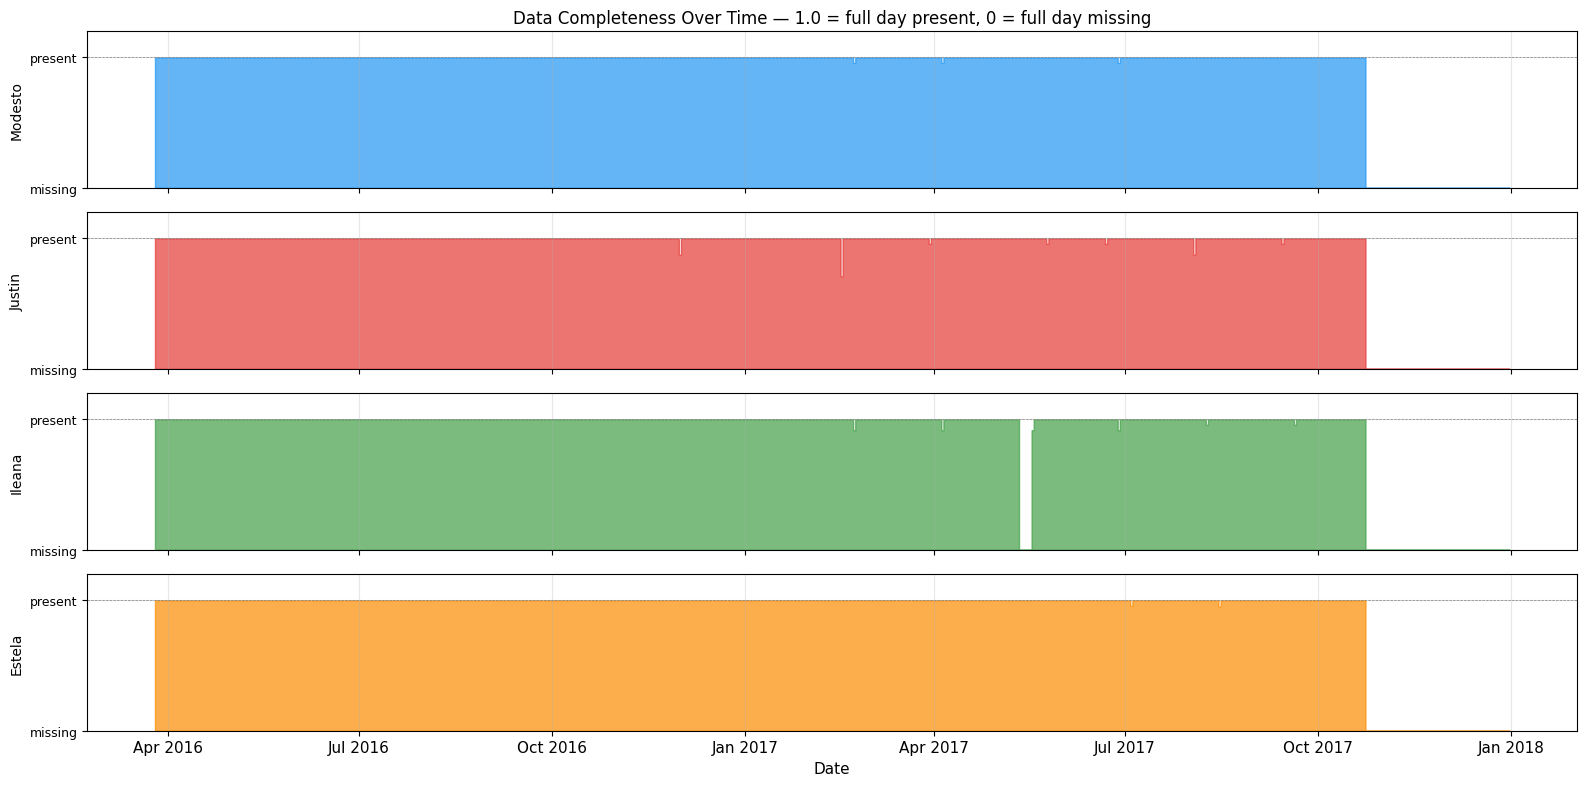

In [35]:
# Visualize WHERE the missing values are over time
# Each row is a building, each column is a time window
# Dark = data present, white = missing

fig, axes = plt.subplots(4, 1, figsize=(16, 8), sharex=True)

# Resample to daily — 1 if any data that day, 0 if all missing
df_daily = df.set_index('timestamp')

for i, (col, color) in enumerate(COLORS.items()):
    # 1 where data exists, 0 where missing
    present = df_daily[col].notna().resample('D').mean()
    axes[i].fill_between(present.index, present.values, 
                          color=color, alpha=0.7, step='mid')
    axes[i].set_ylim(0, 1.2)
    axes[i].set_ylabel(col.replace('_kWh', ''), fontsize=10)
    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels(['missing', 'present'], fontsize=9)
    axes[i].axhline(y=1, color='gray', linewidth=0.5, linestyle='--')

axes[0].set_title('Data Completeness Over Time — 1.0 = full day present, 0 = full day missing',
                   fontsize=12)
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

### ✏️ Exercise 2.1 — Reading the Missing Data Map

In [36]:
# Exercise 2.1 — Answer in comments

# Q1: Are the missing values scattered randomly, or do they cluster 
#     in specific time periods?
# A: Most values are scattered randomly execpt for Ileana, there was a large missing data chunk in summer of 2017

# Q2: Do all four buildings tend to go missing at the same times,
#     or do they have independent gaps?
# A: No they are independent

# Q3: Justin_kWh had a minimum of 0.0 in Part 1. Look at Justin's
#     completeness strip — does this change your thinking about those zeros?
# A: It does, it looks more natural now.

# Q4: When you build a regression model in the next notebook, you will need
#     to decide what to do with missing rows. Based on what you see here,
#     would you drop missing rows entirely, or fill them in somehow?
#     What would you fill them with?
# A: Probally don't count them, it looks like Ileana's power went down for a significant amount of time.

---
## Part 3: Drawing the Distributions

A distribution answers the question: **what values does this variable typically take?**

Before you model anything, you need to know if your data is symmetric, skewed,
bimodal, or bounded. A model that doesn't know about a bimodal distribution will
produce predictions that belong to neither mode — confidently wrong.

We will draw two views: a **histogram** (the shape of the data) and a
**box plot** (the spread, median, and outliers).

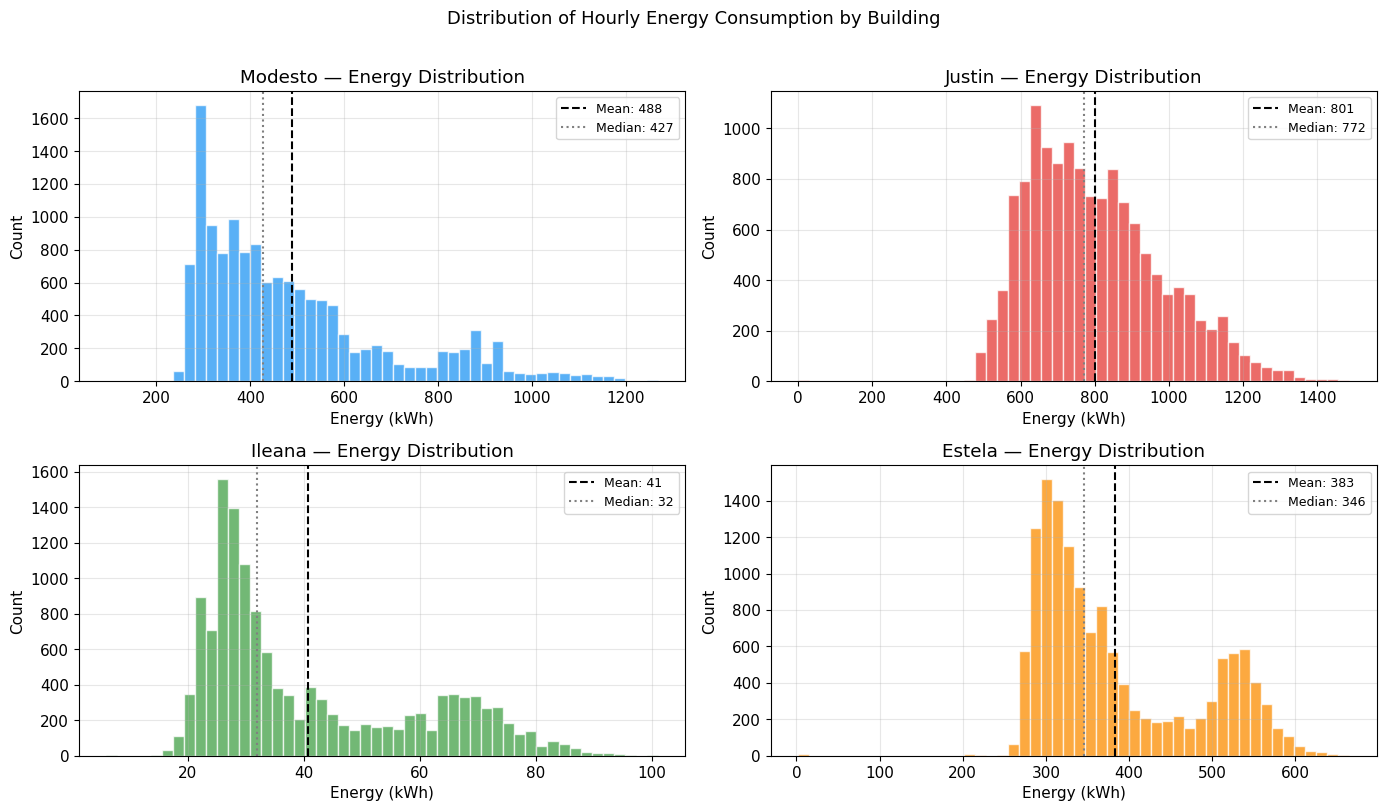

In [37]:
# Histograms — distribution of each building's energy consumption
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(COLORS.items()):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color=color, alpha=0.75, edgecolor='white')
    axes[i].axvline(data.mean(), color='black', linestyle='--', 
                    linewidth=1.5, label=f'Mean: {data.mean():.0f}')
    axes[i].axvline(data.median(), color='gray', linestyle=':',
                    linewidth=1.5, label=f'Median: {data.median():.0f}')
    axes[i].set_title(col.replace('_kWh', '') + ' — Energy Distribution')
    axes[i].set_xlabel('Energy (kWh)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Hourly Energy Consumption by Building', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

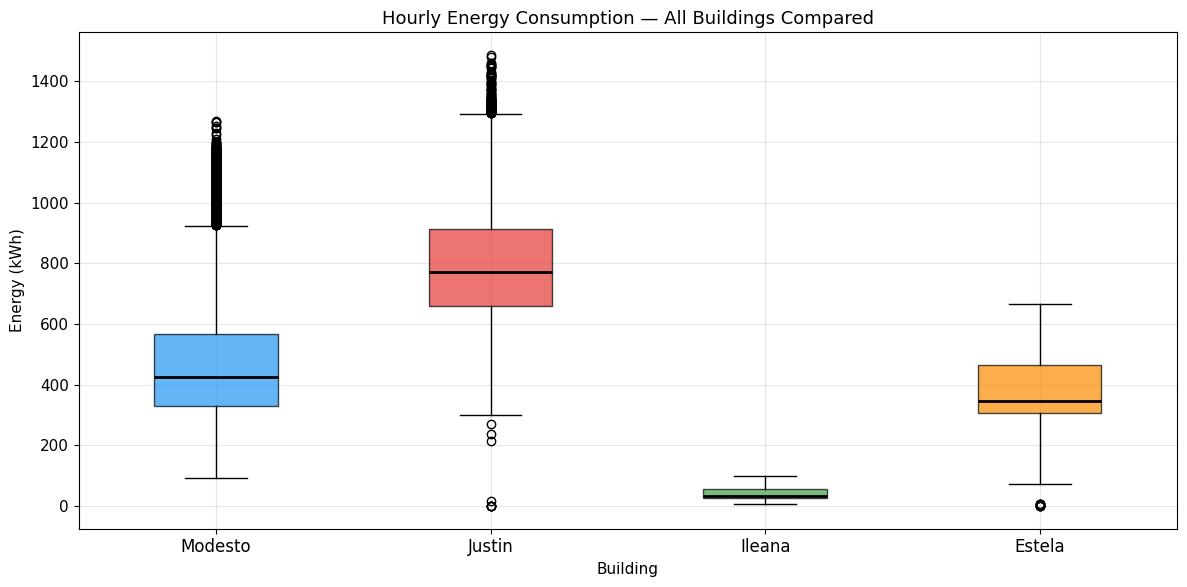

In [38]:
# Box plots — compare all four buildings on the same scale
fig, ax = plt.subplots(figsize=(12, 6))

data_to_plot = [df[col].dropna().values for col in BUILDINGS]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(BUILDING_NAMES, fontsize=12)
ax.set_xlabel('Building')
ax.set_ylabel('Energy (kWh)')
ax.set_title('Hourly Energy Consumption — All Buildings Compared', fontsize=13)
plt.tight_layout()
plt.show()

### ✏️ Exercise 3.1 — Reading the Distributions

In [39]:
# Exercise 3.1 — Answer in comments

# Q1: Look at the histogram shapes. Are any of the distributions bimodal
#     (two humps)? What might cause a bimodal energy distribution 
#     in a healthcare building?
# A: Estela is, this could be due to the building being used as a sort of overflow where more power is needed at certian times

# Q2: In the box plot, which building has the most outliers (dots beyond
#     the whiskers)? What does that tell you about that building's 
#     energy behavior?
# A: Modesto does, this tells that the building has a hihg volatility in power consumption

# Q3: Ileana_kWh has a much smaller range than the other buildings.
#     What kind of healthcare facility might use such stable, low energy?
#     (Think about what types of buildings exist in a hospital campus.)
# A: Could be an office building without major machines.

# Q4: If your regression model predicted 300 kWh for Justin, would that
#     be a reasonable prediction? Use the distribution to justify your answer.
# A: No, justin is rarley using only 300kWh of power.

---
## Part 4: Drawing the Time Series

Energy data lives in time. The same building looks completely different
depending on the scale you use to look at it:

- **Full dataset** — seasonal trends, year-over-year patterns
- **One week** — the weekly rhythm, weekday vs weekend
- **One day** — the hourly pulse of the building

All three views are true simultaneously. A good data storyteller looks at all three
before drawing any conclusions.

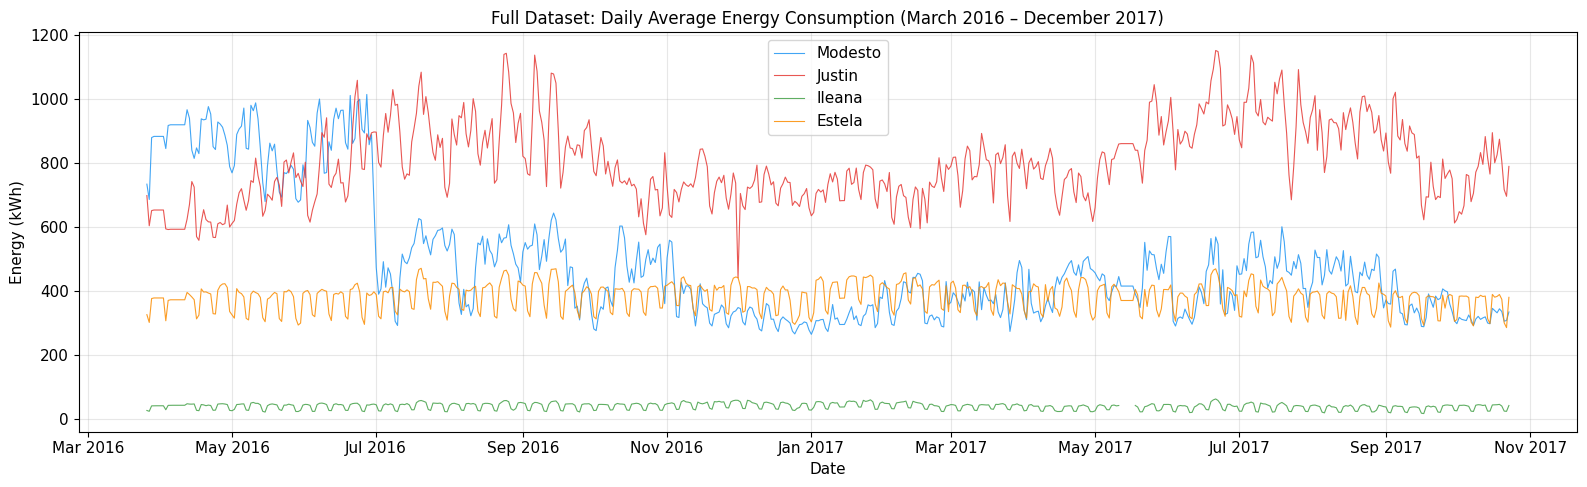

In [40]:
# View 1: Full dataset — daily average for each building
df_daily_avg = df.set_index('timestamp')[BUILDINGS].resample('D').mean()

fig, ax = plt.subplots(figsize=(16, 5))

for col, color in COLORS.items():
    ax.plot(df_daily_avg.index, df_daily_avg[col], 
            color=color, linewidth=0.8, alpha=0.85,
            label=col.replace('_kWh', ''))

ax.set_title('Full Dataset: Daily Average Energy Consumption (March 2016 – December 2017)',
             fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Energy (kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.show()

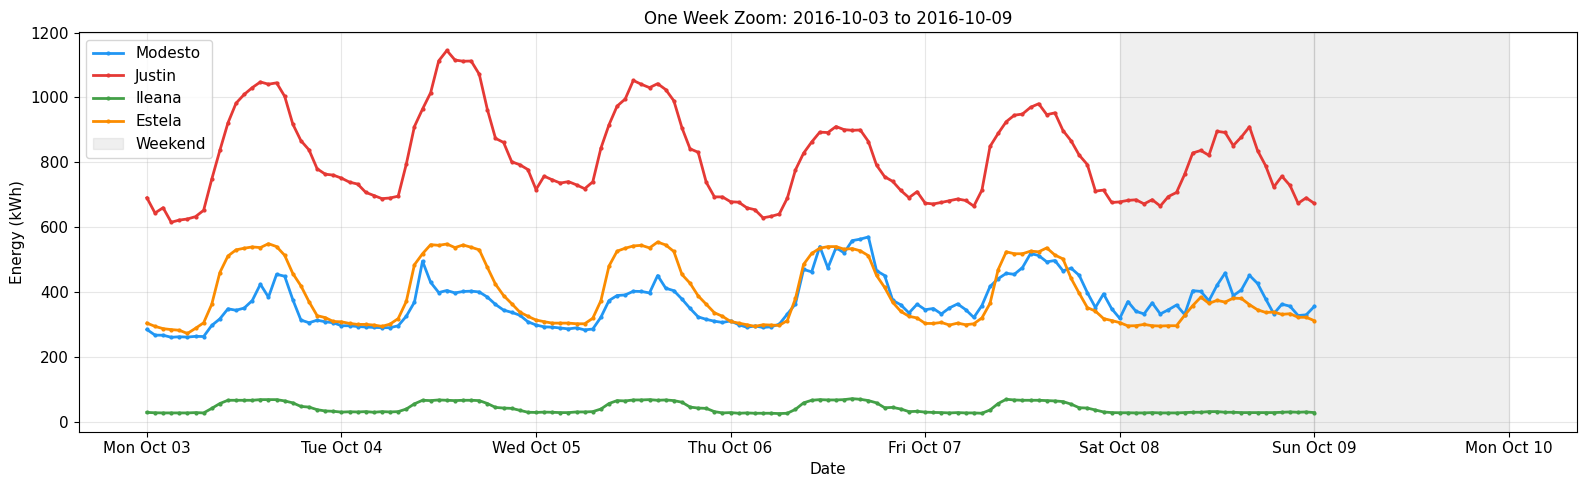

In [41]:
# View 2: One week zoom — pick a representative week
# Using a week in October 2016 — adjust if you want a different period
week_start = '2016-10-03'
week_end   = '2016-10-09'

df_week = df[(df['timestamp'] >= week_start) & 
             (df['timestamp'] <= week_end)].copy()

fig, ax = plt.subplots(figsize=(16, 5))

for col, color in COLORS.items():
    ax.plot(df_week['timestamp'], df_week[col],
            color=color, linewidth=2, marker='o', markersize=2,
            label=col.replace('_kWh', ''))

# Shade weekends
for day_offset in range(7):
    day = pd.Timestamp(week_start) + pd.Timedelta(days=day_offset)
    if day.dayofweek >= 5:  # Saturday or Sunday
        ax.axvspan(day, day + pd.Timedelta(days=1), 
                   alpha=0.12, color='gray', label='Weekend' if day_offset == 5 else '')

ax.set_title(f'One Week Zoom: {week_start} to {week_end}', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Energy (kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %b %d'))
ax.legend()
plt.tight_layout()
plt.show()

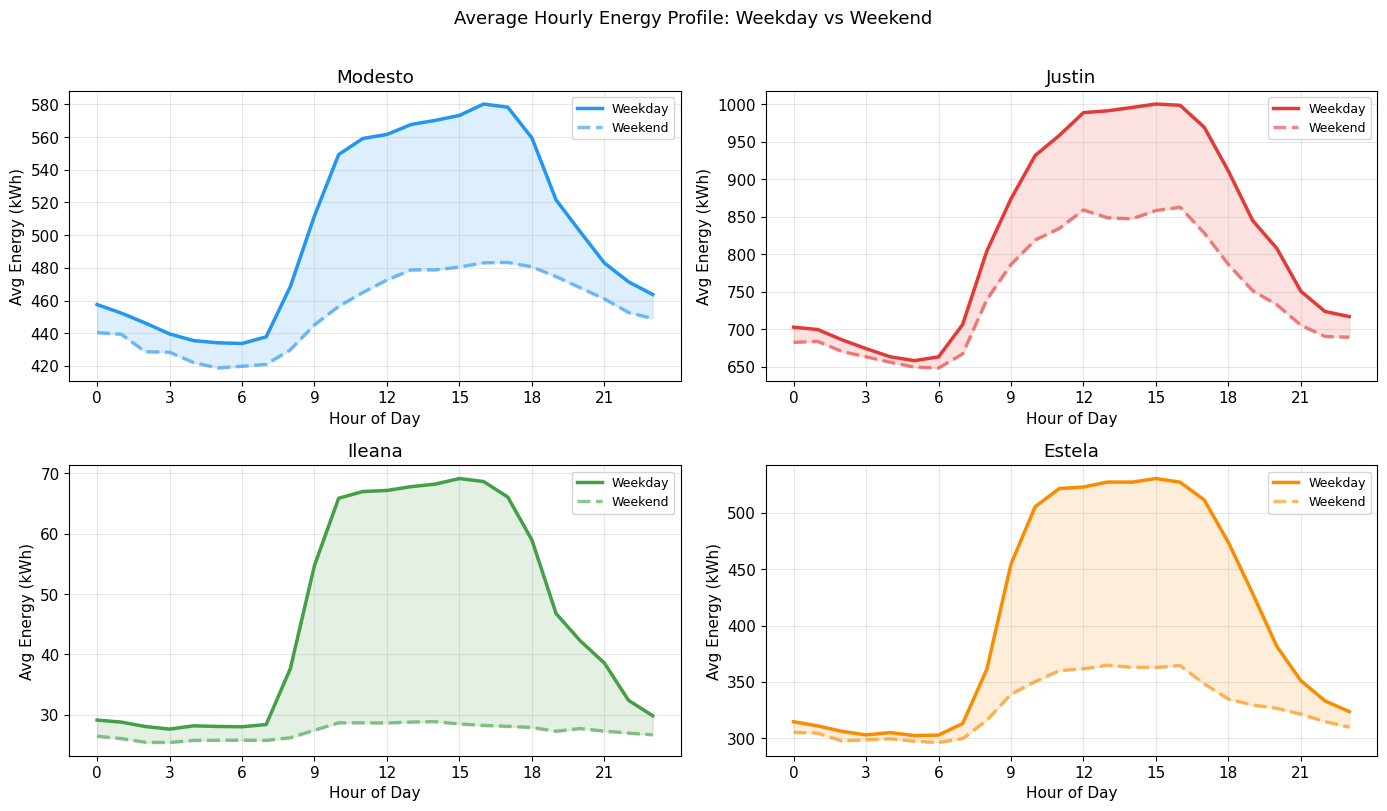

In [42]:
# View 3: Average hourly profile — weekday vs weekend
# This shows the typical "pulse" of each building across a day

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(COLORS.items()):
    weekday = df[df['is_weekend'] == 0].groupby('hour')[col].mean()
    weekend = df[df['is_weekend'] == 1].groupby('hour')[col].mean()
    
    axes[i].plot(weekday.index, weekday.values, 
                 color=color, linewidth=2.5, label='Weekday')
    axes[i].plot(weekend.index, weekend.values,
                 color=color, linewidth=2.5, linestyle='--', 
                 alpha=0.6, label='Weekend')
    axes[i].fill_between(weekday.index, weekday.values, weekend.values,
                          alpha=0.15, color=color)
    axes[i].set_title(col.replace('_kWh', ''))
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('Avg Energy (kWh)')
    axes[i].set_xticks(range(0, 24, 3))
    axes[i].legend(fontsize=9)

plt.suptitle('Average Hourly Energy Profile: Weekday vs Weekend', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### ✏️ Exercise 4.1 — Reading the Time Series

In [43]:
# Exercise 4.1 — Answer in comments

# Q1: In the full dataset view, do you see a seasonal pattern?
#     Which months tend to have higher energy demand?
# A: The summer to early fall months tend to have the highest energy demand.

# Q2: In the one-week zoom, can you identify weekdays vs weekends
#     just by looking at the energy curves? Describe what you see.
# A: In most buildings the energy consumption is much lower on the weekends, almost dropping to a flat line

# Q3: In the hourly profile, which building shows the MOST difference
#     between weekday and weekend behavior? What does that suggest
#     about what that building is used for?
# A: Ileana shows the greatest difference, this shows that the building is likley not being used to treat patients but is instead an office/managment building.

# Q4: At what hour of the day does energy demand typically peak 
#     for the highest-consuming building?
# A: Justin typically peaks at 15

# Q5: A fellow student says "I'll just use hourly data to train my model —
#     I don't need to add hour or day_of_week as features because the 
#     timestamp is already there."
#     Using what you've drawn here, explain why they are wrong.
# A: A model trained on hourly data only will not take in the effect that differtn days of the week or seasons have, so it may predict the same energy need on saturday as monday, which would be incorrect.

---
## Part 5: Drawing the Relationships

Your regression model's job is to find relationships between features and
energy demand. But you should see those relationships yourself before the
model does. If you can't see a relationship in a scatter plot, a linear
model probably can't find one either.

The most important relationship to investigate first: **temperature and energy**.
Does warmer weather mean more energy use? Less? Does it depend on the building?

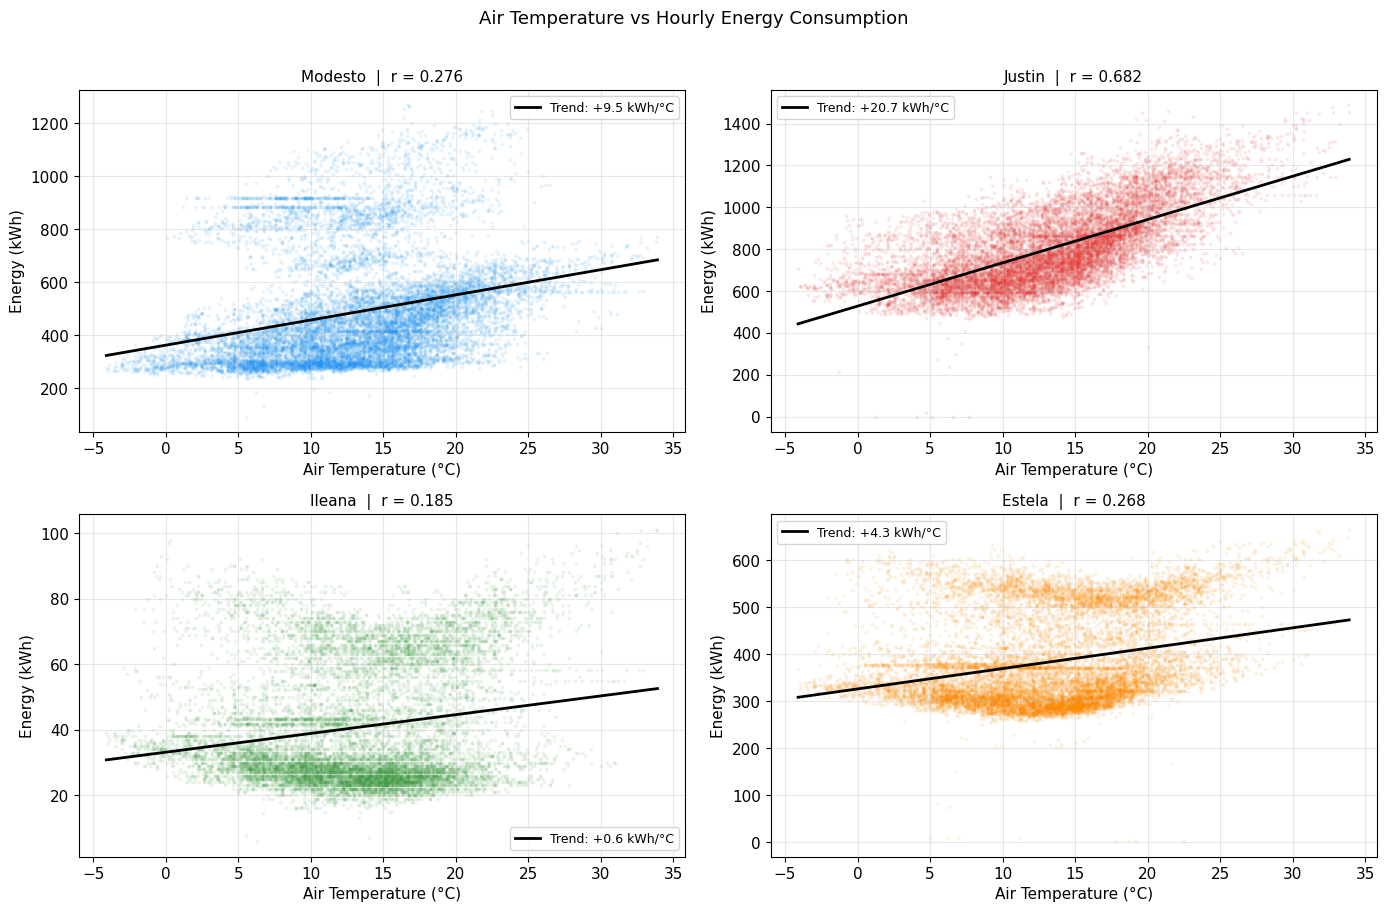

In [44]:
# Scatter plots: air temperature vs each building's energy
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (col, color) in enumerate(COLORS.items()):
    # Drop rows where either value is missing
    mask = df[col].notna() & df['airTemperature'].notna()
    x = df.loc[mask, 'airTemperature']
    y = df.loc[mask, col]
    
    axes[i].scatter(x, y, color=color, alpha=0.08, s=3)
    
    # Add a trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_line, p(x_line), color='black', linewidth=2,
                 label=f'Trend: {z[0]:+.1f} kWh/°C')
    
    # Correlation coefficient
    corr = x.corr(y)
    axes[i].set_title(f'{col.replace("_kWh","")}  |  r = {corr:.3f}', fontsize=11)
    axes[i].set_xlabel('Air Temperature (°C)')
    axes[i].set_ylabel('Energy (kWh)')
    axes[i].legend(fontsize=9)

plt.suptitle('Air Temperature vs Hourly Energy Consumption', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

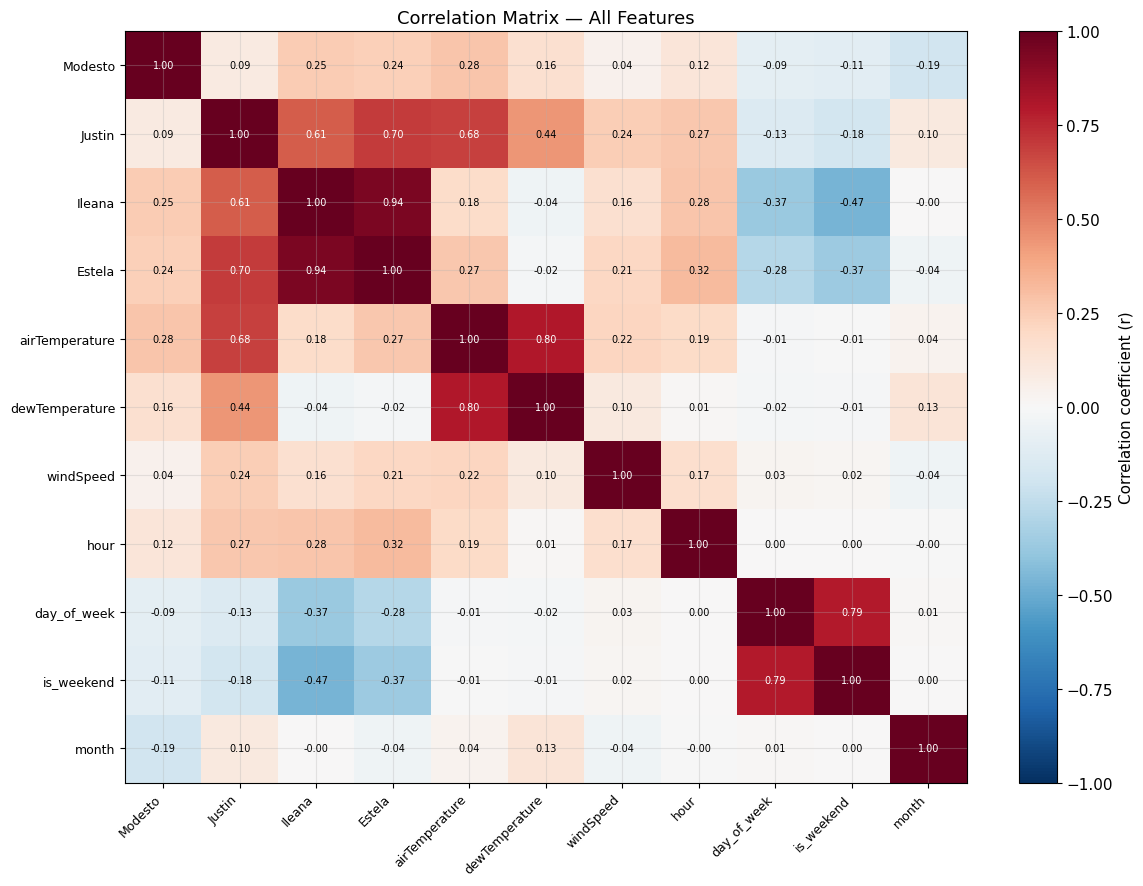

In [45]:
# Correlation matrix — how do ALL features relate to each other?
features = BUILDINGS + ['airTemperature', 'dewTemperature', 
                         'windSpeed', 'hour', 'day_of_week', 'is_weekend', 'month']

corr_matrix = df[features].corr().round(3)

# Display as a heatmap using matplotlib
fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels([f.replace('_kWh','') for f in features], 
                    rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([f.replace('_kWh','') for f in features], fontsize=9)

# Add correlation values as text
for i in range(len(features)):
    for j in range(len(features)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Correlation coefficient (r)')
ax.set_title('Correlation Matrix — All Features', fontsize=13)
plt.tight_layout()
plt.show()

### ✏️ Exercise 5.1 — Reading the Relationships

In [46]:
# Exercise 5.1 — Answer in comments

# Q1: Which building has the strongest correlation with air temperature?
#     Is it positive or negative? What does that mean physically?
# A: Justin has the highest correlation with the air temperature, it is positive. This means that Justin is likley using the most Air Conditioning to cool its self

# Q2: Which building has the weakest correlation with temperature?
#     What might that tell you about how that building uses energy?
# A: Ileana has the weakest correlation, so that building likley allocates most of its resources to things other than climate control

# Q3: Look at the correlation matrix. Which non-temperature feature
#     has the strongest correlation with energy demand across buildings?
# A: The hour has the highest correlation

# Q4: airTemperature and dewTemperature are highly correlated with each other.
#     When two input features are highly correlated, it is called 
#     'multicollinearity'. Why might this cause problems in a regression model?
# A: It would make it difficult for the model to determine how much each feature individually contributes  to the output.

# Q5: Based on everything you have drawn so far, write a one-sentence 
#     hypothesis: which feature do you think will be the single strongest
#     predictor of energy demand in your regression model, and why?
# A: I think that the hour of the day will be the strongest predictor of energy demand, while air temperature has a higher correlation with justin, the hour has a higher correlation for every other building.

---
## Part 6: Your Team's Data Profile

The Data Profile is your team's written summary of what you discovered.
It is not a homework assignment — it is a reference document.
You will look back at it when you are interpreting your regression results
and asking "does this prediction make sense?"

Fill in every field. Be specific. Use numbers from the visualizations above.

**This is a contest deliverable — submit it with your Week 1 materials.**

In [47]:
# Run this cell to generate your Data Profile template
# Replace each [FILL IN] with your team's answer

profile = """
╔══════════════════════════════════════════════════════════════════╗
║                     TEAM DATA PROFILE                           ║
║              Smart City AI Contest — Week 1                     ║
╚══════════════════════════════════════════════════════════════════╝

Team Name:        Late people
Date Completed:   5/18/2026

── DATASET DIMENSIONS ─────────────────────────────────────────────
Total rows:              15,480
Total columns:           14
Date range:              2016-03-26 to 2017-12-31
Time resolution:         hourly (hourly / 15-min / daily)
Number of buildings:     4

── MISSING DATA ───────────────────────────────────────────────────
Building with most missing data:    Ileana  ( 11.7 % )
Building with least missing data:   Estela  ( 10.7 % )
Are gaps random or clustered?       Random execpt for Ileana
Our plan for handling missing data: Dont count

── ENERGY RANGES ──────────────────────────────────────────────────
Modesto typical range:  329.82	 – 568.18 kWh
Justin  typical range:  658.13	 – 912.31 kWh
Ileana  typical range:  26.00 – 56.00 kWh
Estela  typical range:  307.00	 – 465.57 kWh

── TIME PATTERNS ──────────────────────────────────────────────────
Peak hour of day (which building, what hour):  Justin, 15
Weekday vs weekend difference (describe):      Consumption lowered on weekend
Seasonal pattern visible?                      Yes, more during warmer months

── RELATIONSHIPS ──────────────────────────────────────────────────
Strongest correlation with temperature (building + r value):  Justin, 0.682
Weakest correlation with temperature  (building + r value):   Ileana, 0.185
Most important non-temperature feature:                       Hour

── DATA CONCERNS ──────────────────────────────────────────────────
One data quality issue we found:    Large amounts of missing data ~10%
How we plan to handle it:           Skip timestamps with missing 
energy data, as 0 would lower the average creating an incorect result

── TEAM HYPOTHESIS ────────────────────────────────────────────────
We predict the strongest feature in our regression model will be:
Hour of day

Because:
Has the highest correlation with all buildings, air tempeture has 
a high correlation with Justin, but not other buildings

We will check this hypothesis against our actual model results
at the end of the regression notebook.

══════════════════════════════════════════════════════════════════
"""

print(profile)


╔══════════════════════════════════════════════════════════════════╗
║                     TEAM DATA PROFILE                           ║
║              Smart City AI Contest — Week 1                     ║
╚══════════════════════════════════════════════════════════════════╝

Team Name:        Late people
Date Completed:   5/18/2026

── DATASET DIMENSIONS ─────────────────────────────────────────────
Total rows:              15,480
Total columns:           14
Date range:              2016-03-26 to 2017-12-31
Time resolution:         hourly (hourly / 15-min / daily)
Number of buildings:     4

── MISSING DATA ───────────────────────────────────────────────────
Building with most missing data:    Ileana  ( 11.7 % )
Building with least missing data:   Estela  ( 10.7 % )
Are gaps random or clustered?       Random execpt for Ileana
Our plan for handling missing data: Dont count

── ENERGY RANGES ──────────────────────────────────────────────────
Modesto typical range:  329.82	 – 568.18 kWh
J

---
## Bonus: Your Own Drawing

The visualizations above were given to you. This exercise is open-ended —
make one plot of your own that shows something interesting about this dataset
that the provided plots did not show.

There is no single right answer. Some ideas:
- Compare energy demand in summer vs winter months
- Plot all four buildings on the same axes for a single day
- Show how wind speed relates to energy demand
- Plot the ratio of one building's demand to another over time

Be prepared to explain what your plot shows and why it might matter
for the regression model.

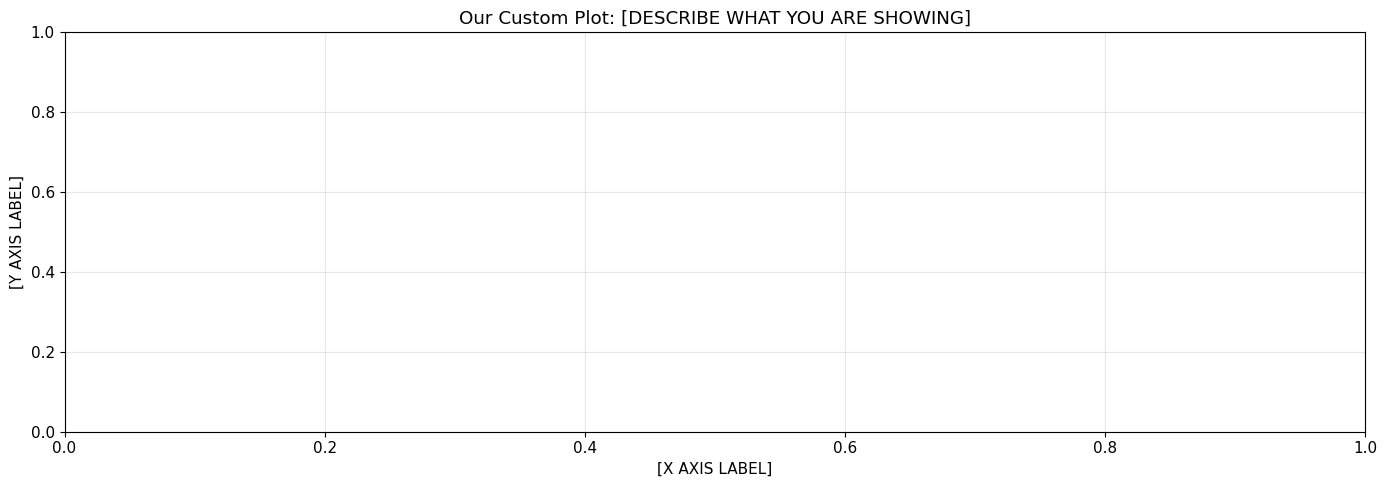

In [48]:
# Bonus — your original visualization
# YOUR CODE HERE

fig, ax = plt.subplots(figsize=(14, 5))

# Add your plot here

ax.set_title('Our Custom Plot: [DESCRIBE WHAT YOU ARE SHOWING]')
ax.set_xlabel('[X AXIS LABEL]')
ax.set_ylabel('[Y AXIS LABEL]')
plt.tight_layout()
plt.show()

# What does this plot show?
# A: 

# Why might this be useful for the regression model?
# A: 

---
## What Comes Next

You have drawn the data. You know its shape, its gaps, its distributions,
its time patterns, and its relationships.

In the next notebook you will build a regression model to predict energy demand.
Every decision that model makes — which features to use, how to handle missing values,
whether a prediction is reasonable — will be informed by what you drew here.

Keep your Data Profile open. You will need it.

---
*Quick Start Orange County: AI Design Contest — Week 1 – University of Florida*